In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential # Builds the layers one by one
from tensorflow.keras.layers import Dense #creates a fully connected layer

In [2]:
# Create a simple feed forward neural network
model = Sequential() #initialize the model
model.add(Dense(4, activation='relu', input_shape=(2,))) #input layer
model.add(Dense(3, activation='relu')) #hidden layer
model.add(Dense(1, activation='sigmoid')) #output layer

/Users/swatichandna/.pyenv/versions/3.11.7/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Import libraries
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np


# Sample data # Training texts (movie reviews)
texts = [
    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent story",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Worst acting ever"
]

# Labels
# 1 = Positive
# 0 = Negative

labels = np.array([1, 1, 1, 1, 0, 0, 0, 0])


# Create a Bag-of-Words vectorizer
vectorizer = CountVectorizer()

# Convert texts to numeric vectors
X = vectorizer.fit_transform(texts).toarray()

#Show all words learned from the dataset
print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nNumeric representation:")
print(X)


# Build FFNN
model = Sequential()
# Input layer + hidden layer
#  X.shape[1]: We set the input shape to the number of features (words) in our BoW representation
#8 = number of neurons in hidden layer
model.add(Dense(8,activation='relu',input_shape=(X.shape[1],)))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
model.summary()

# Train the model
history = model.fit(X, labels,
          epochs=100, #number of times the model will see the entire dataset
          verbose=0) #verbose=0 means no output during training


# Test the model with a new review
new_text = ["Amazing acting and good story"]

# Convert the new text to a numeric vector using the same vectorizer
new_vector = vectorizer.transform(new_text).toarray()

# Make a prediction
prediction = model.predict(new_vector)

print("\nProbability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

Vocabulary:
['acting' 'amazing' 'boring' 'ever' 'excellent' 'film' 'good' 'hate' 'is'
 'love' 'movie' 'story' 'terrible' 'this' 'very' 'worst']

Numeric representation:
[[0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0]
 [0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1]]


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Probability: 0.6712448
Positive Review


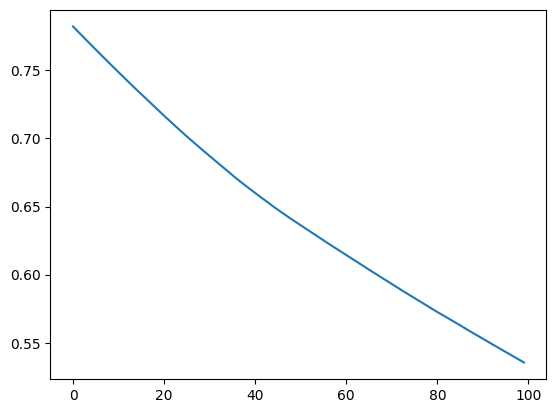

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


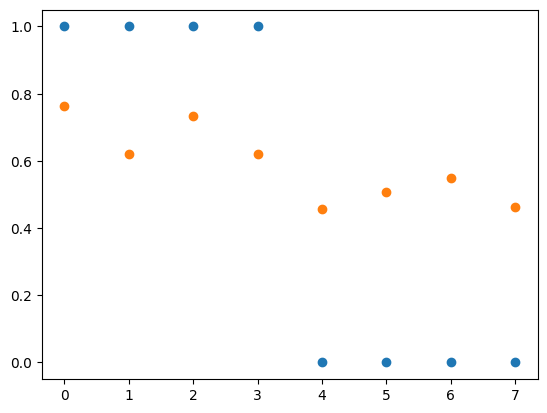

In [11]:
import matplotlib.pyplot as plt
# Training loss
plt.plot(history.history['loss'])
plt.show()

# Predictions
predictions = model.predict(X).flatten()

plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()